In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/hantavirus_outbreaks.csv
/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/hantavirus_country_yearly.csv
/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/data_dictionary.csv
/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/hantavirus_clinical.csv
/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/hantavirus_environmental.csv
/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/sources_metadata.csv
/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/hantavirus_virus_strains.csv
/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/hantavirus_master.csv
/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/Hantavirus_Andes_Global_Registry.csv
/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidem

In [2]:
df = pd.read_csv('/kaggle/input/datasets/zkskhurram/hantavirus-andes-virus-global-epidemiology/hantavirus_country_yearly.csv')
df.head()

,year,iso3,country,who_region,latitude,longitude,syndrome,confirmed_cases,deaths,recovered,case_fatality_rate,hospitalized,icu_admissions,human_to_human_cases
0,1993,ARG,Argentina,AMRO,-34.6,-58.4,HPS,35,11,24,0.3426,30,8,0
1,1993,CHL,Chile,AMRO,-33.4,-70.6,HPS,0,0,0,0.2587,0,0,0
2,1993,BRA,Brazil,AMRO,-15.8,-47.9,HPS,0,0,0,0.4455,0,0,0
3,1993,BOL,Bolivia,AMRO,-16.5,-68.2,HPS,0,0,0,0.2775,0,0,0
4,1993,PRY,Paraguay,AMRO,-25.3,-57.6,HPS,0,0,0,0.2666,0,0,0


In [3]:
df.describe()

,year,latitude,longitude,confirmed_cases,deaths,recovered,case_fatality_rate,hospitalized,icu_admissions,human_to_human_cases
count,850.000000,850.00000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000
mean,2009.500000,23.77880,-3.594800,780.403529,21.878824,758.524706,0.149206,645.784706,177.734118,0.121176
std,9.816485,31.97926,69.203811,2322.245227,69.542629,2258.739647,0.152619,1930.355520,556.878442,0.649834
min,1993.000000,-34.90000,-84.100000,0.000000,0.000000,0.000000,0.001000,0.000000,0.000000,0.000000
25%,2001.000000,4.70000,-68.200000,8.000000,0.000000,7.000000,0.013325,6.000000,1.000000,0.000000
50%,2009.500000,37.97000,2.300000,30.000000,1.000000,23.000000,0.037050,25.500000,6.000000,0.000000
75%,2018.000000,48.90000,23.730000,140.750000,7.000000,134.000000,0.309375,114.750000,31.000000,0.000000
max,2026.000000,60.20000,139.700000,14377.000000,532.000000,13913.000000,0.445500,11588.000000,4363.000000,7.000000


In [4]:
df.isnull().sum()

year                    0
iso3                    0
country                 0
who_region              0
latitude                0
longitude               0
syndrome                0
confirmed_cases         0
deaths                  0
recovered               0
case_fatality_rate      0
hospitalized            0
icu_admissions          0
human_to_human_cases    0
dtype: int64

In [5]:
print(df.columns.dtype)

object


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['iso3'] = le.fit_transform(df['iso3'])
df['country'] = le.fit_transform(df['country'])
df['who_region'] = le.fit_transform(df['who_region'])
df['syndrome'] = le.fit_transform(df['syndrome'])

In [7]:
print(df.dtypes)

year                      int64
iso3                      int64
country                   int64
who_region                int64
latitude                float64
longitude               float64
syndrome                  int64
confirmed_cases           int64
deaths                    int64
recovered                 int64
case_fatality_rate      float64
hospitalized              int64
icu_admissions            int64
human_to_human_cases      int64
dtype: object


In [8]:
df.dropna(inplace=True)

In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.head()
df.tail()

,year,iso3,country,who_region,latitude,longitude,syndrome,confirmed_cases,deaths,recovered,case_fatality_rate,hospitalized,icu_admissions,human_to_human_cases
845,2026,20,18,1,46.10,14.50,0,50,0,50,0.0116,40,12,0
846,2026,13,13,1,37.97,23.73,0,20,0,20,0.0349,18,3,0
847,2026,12,23,1,51.50,-0.10,0,11,0,11,0.0238,9,2,0
848,2026,22,21,2,25.00,121.50,0,6,0,6,0.0147,5,1,0
849,2026,7,7,0,4.70,-74.10,1,4,1,3,0.3558,3,0,0


In [11]:
df['icu_to_hospital_ratio'] = df['icu_admissions'] / (df['hospitalized'] + 1e-5)
df['hospitalization_rate'] = df['hospitalized'] / (df['confirmed_cases'] + 1e-5)
df['distance_from_equator'] = df['latitude'].abs()
df['is_northern_hemisphere'] = (df['latitude'] > 0).astype(int)
region_fatality = df.groupby('who_region')['case_fatality_rate'].transform('mean')
df['region_avg_fatality'] = region_fatality
df['syndrome_region'] = df['syndrome'].astype(str) + "_" + df['who_region'].astype(str)
df['h2h_intensity'] = df['confirmed_cases'] * df['human_to_human_cases']


In [12]:
y = df['deaths']
X = df.drop('deaths',axis=1)
X = df.drop('human_to_human_cases', axis=1)
print(X.shape)
print(X.columns.to_list())

(850, 20)
['year', 'iso3', 'country', 'who_region', 'latitude', 'longitude', 'syndrome', 'confirmed_cases', 'deaths', 'recovered', 'case_fatality_rate', 'hospitalized', 'icu_admissions', 'icu_to_hospital_ratio', 'hospitalization_rate', 'distance_from_equator', 'is_northern_hemisphere', 'region_avg_fatality', 'syndrome_region', 'h2h_intensity']


In [13]:
from sklearn.model_selection import train_test_split
train_X , val_X , train_y , val_y = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=500, max_depth=5, max_samples = 0.5, random_state=42)
model.fit(train_X, train_y)

from sklearn.metrics import accuracy_score
prediction = model.predict(val_X)

accuracy = accuracy_score(val_y, prediction)

print(f'Accuracy for RFC is {accuracy}')

Accuracy for RFC is 0.6588235294117647


In [15]:
from xgboost import XGBClassifier


# le = LabelEncoder()
train_y_encoded = le.fit_transform(train_y)

val_y_encoded = np.array([le.transform([x])[0] if x in le.classes_ else -1 for x in val_y])
valid_idx = val_y_encoded != -1
val_X_filtered = val_X[valid_idx].copy()
val_y_filtered = val_y_encoded[valid_idx]

train_X['syndrome_region'] = train_X['syndrome_region'].astype('category')
val_X_filtered['syndrome_region'] = val_X_filtered['syndrome_region'].astype('category')

xgb = XGBClassifier(
    n_estimators=500, 
    max_depth=5, 
    subsample=0.5,             
    random_state=42,
    enable_categorical=True    
)

xgb.fit(train_X, train_y_encoded)
prediction = xgb.predict(val_X_filtered)

accuracy = accuracy_score(val_y_filtered, prediction)
print(f'Accuracy for XGB is {accuracy}')

Accuracy for XGB is 0.9044585987261147


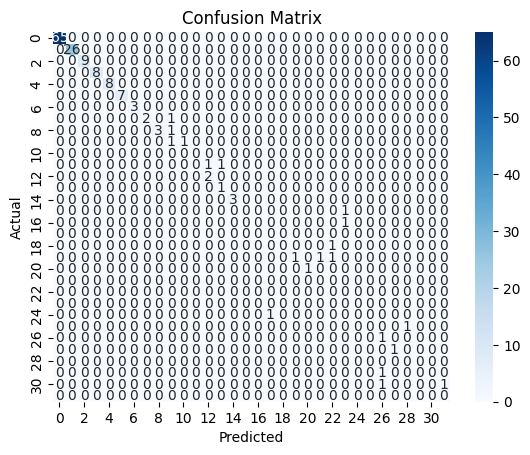

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(val_y_filtered, prediction)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()